Model Tuning Round 1

In [26]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_model_round1(dense_units=256, dropout_rate=0.5, learning_rate=1e-4):
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # freeze all convolutional layers

    # Image branch
    img_input = Input(shape=(224, 224, 3))
    x = base_model(img_input)
    x = Flatten()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Metadata branch
    meta_input = Input(shape=(X_meta.shape[1],))
    m = Dense(64, activation='relu')(meta_input)
    m = Dropout(0.3)(m)

    # Combine
    combined = Concatenate()([x, m])
    z = Dense(128, activation='relu')(combined)
    z = Dropout(0.3)(z)
    output = Dense(len(label_encoder.classes_), activation='softmax')(z)

    model = Model(inputs=[img_input, meta_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Example: Try one Round 1 config
model_r1 = build_model_round1(dense_units=256, dropout_rate=0.4, learning_rate=1e-4)

history_r1 = model_r1.fit(
    [X_img_train, X_meta_train], y_train,
    validation_data=([X_img_val, X_meta_val], y_val),
    epochs=5,
    batch_size=32,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ModelCheckpoint("round1_best_model.h5", save_best_only=True)
    ]
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4010 - loss: 1.3998

125/125 ━━━━━━━━━━━━━━━━━━━━ 568s 5s/step - accuracy: 0.4018 - loss: 1.3981 - val_accuracy: 0.7300 - val_loss: 0.7574
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6634 - loss: 0.8555

125/125 ━━━━━━━━━━━━━━━━━━━━ 582s 5s/step - accuracy: 0.6635 - loss: 0.8554 - val_accuracy: 0.7500 - val_loss: 0.6742
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7328 - loss: 0.7165

125/125 ━━━━━━━━━━━━━━━━━━━━ 577s 5s/step - accuracy: 0.7328 - loss: 0.7164 - val_accuracy: 0.7590 - val_loss: 0.6337
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7761 - loss: 0.6110

125/125 ━━━━━━━━━━━━━━━━━━━━ 597s 5s/step - accuracy: 0.7761 - loss: 0.6110 - val_accuracy: 0.7550 - val_loss: 0.6254
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7942 - loss: 0.5568

125/125 ━━━━━━━━━━━━━━━━━━━━ 575s 5s/step - accuracy: 0.7943 - loss: 0.5567 - val_accuracy: 0.7560 - val_loss: 0.6136


Model Tuning Round 2 

In [29]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_model_round2_optimized():
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

    #Unfreeze only the last 2 convolutional layers
    for layer in base_model.layers[:-2]:
        layer.trainable = False
    for layer in base_model.layers[-2:]:
        layer.trainable = True

    #Image Input Branch
    img_input = Input(shape=(224, 224, 3))
    x = base_model(img_input)
    x = GlobalAveragePooling2D()(x) 
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    #Metadata Branch
    meta_input = Input(shape=(X_meta.shape[1],))
    m = Dense(64, activation='relu')(meta_input)
    m = Dropout(0.3)(m)

    #Combine and Output
    combined = Concatenate()([x, m])
    z = Dense(64, activation='relu')(combined)
    z = Dropout(0.3)(z)
    output = Dense(len(label_encoder.classes_), activation='softmax')(z)

    model = Model(inputs=[img_input, meta_input], outputs=output)
    model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    return model

#Build and Train Optimized Round 2 Model
model_r2 = build_model_round2_optimized()

history_r2 = model_r2.fit(
    [X_img_train, X_meta_train], y_train,
    validation_data=([X_img_val, X_meta_val], y_val),
    epochs=5,         
    batch_size=16,           
    callbacks=[
        EarlyStopping(patience=2, restore_best_weights=True),
        ModelCheckpoint("round2_finetuned_optimized.h5", save_best_only=True)
    ]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2000 - loss: 1.6605

250/250 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.2001 - loss: 1.6603 - val_accuracy: 0.3460 - val_loss: 1.5262
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3115 - loss: 1.5267

250/250 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.3116 - loss: 1.5266 - val_accuracy: 0.5480 - val_loss: 1.3561
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4293 - loss: 1.3818

250/250 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.4294 - loss: 1.3817 - val_accuracy: 0.6290 - val_loss: 1.1862
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4947 - loss: 1.2617

250/250 ━━━━━━━━━━━━━━━━━━━━ 598s 2s/step - accuracy: 0.4948 - loss: 1.2617 - val_accuracy: 0.6780 - val_loss: 1.0583
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5417 - loss: 1.1778

250/250 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.5417 - loss: 1.1777 - val_accuracy: 0.7000 - val_loss: 0.9628


In [34]:
# Round 1
loss1, acc1 = model_r1.evaluate([X_img_test, X_meta_test], y_test_cat, verbose=0)

# Round 2
loss2, acc2 = model_r2.evaluate([X_img_test, X_meta_test], y_test_cat, verbose=0)

print(f"Round 1 Accuracy: {acc1:.4f} | Loss: {loss1:.4f}")
print(f"Round 2 Accuracy: {acc2:.4f} | Loss: {loss2:.4f}")

Round 1 Accuracy: 0.7202 | Loss: 0.7607
Round 2 Accuracy: 0.6379 | Loss: 1.0379


In [44]:
if acc2 > acc1:
    best_model = model_r2
    best_name = "Round 2 (Fine-tuned)"
else:
    best_model = model_r1
    best_name = "Round 1 (Frozen VGG)"
print(f"Best Model Selected: {best_name}")

Best Model Selected: Round 1 (Frozen VGG)


Model Interpretability 

In [52]:
# Predict class probabilities
y_pred_probs = best_model.predict([X_img_test, X_meta_test])

# Predicted classes
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# True classes
y_true_classes = np.argmax(y_test_cat, axis=1)

136/136 ━━━━━━━━━━━━━━━━━━━━ 469s 3s/step


<Figure size 800x600 with 0 Axes>

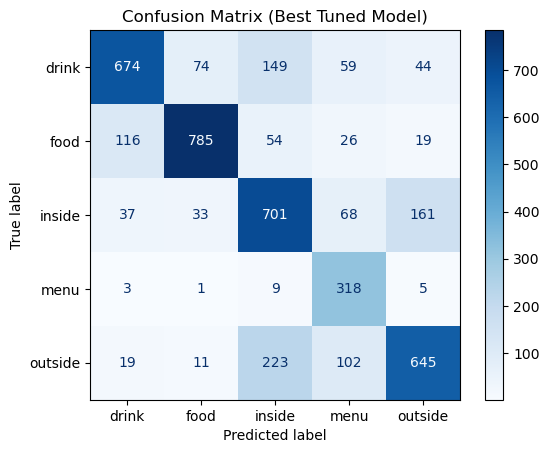

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Best Tuned Model)")
plt.show()

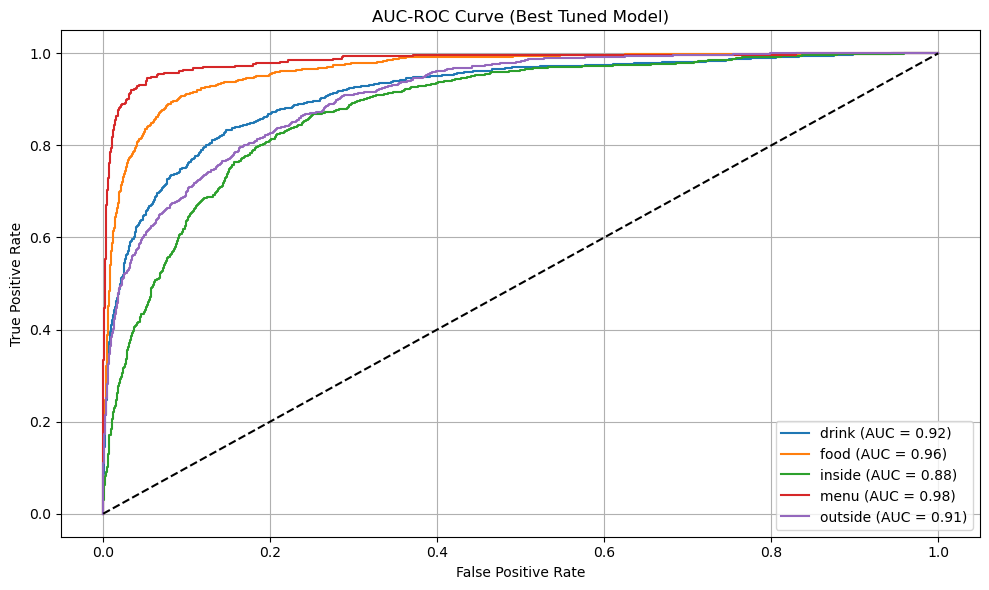

In [54]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true classes
y_true_bin = label_binarize(y_true_classes, classes=list(range(len(label_encoder.classes_))))

# AUC-ROC
plt.figure(figsize=(10, 6))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("AUC-ROC Curve (Best Tuned Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

In [45]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [50]:
import random

# Choose a new random sample index from the test set
sample_index = random.randint(0, len(X_img_test) - 1)

# Extract new sample
img_sample = X_img_test[sample_index:sample_index+1]
meta_sample = X_meta_test[sample_index:sample_index+1]
true_label = np.argmax(y_test_cat[sample_index])
true_label_name = label_encoder.classes_[true_label]

print(f"New Sample Index: {sample_index}")
print(f"True Label: {true_label_name}")

New Sample Index: 2216
True Label: inside


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

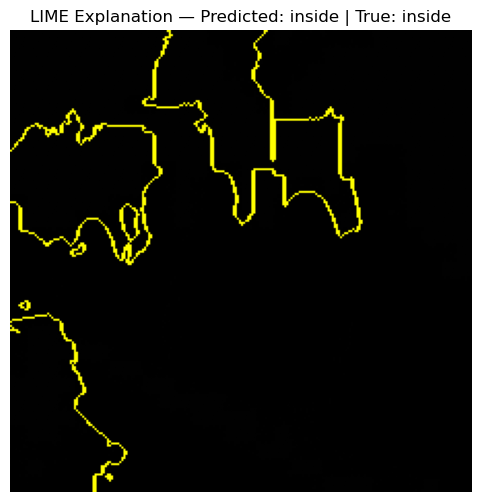

In [51]:
# Predict class for selected sample
predicted_class_index = np.argmax(best_model.predict([img_sample, meta_sample])[0])
predicted_class_label = label_encoder.classes_[predicted_class_index]

# Re-run LIME image explanation
exp_img = explainer_img.explain_instance(
    img_sample[0],
    predict_image_only,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = exp_img.get_image_and_mask(
    label=predicted_class_index,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation — Predicted: {predicted_class_label} | True: {true_label_name}")
plt.axis('off')
plt.show()

In [ ]:
#First prompt : how can I add custom layer on vgg and tell me how its working explain step by steps.
#Last promt : how model fine tuning work explain me.
